# Overview of the project

In one sentence: **Decoding False Memorability from Human Inferior Temporal Cortex and Testing Brain–Model Alignment**

- Domain and Goal
	- This project lies at the intersection of cognitive neuroscience (vision + memory) and computational modeling, with an AI-alignment motivation
	- I want to identify what human visual cortex represents beyond object recognition, and use those findings to evaluate and guide multi-task vision models

- Research Questions
	1. Decoding: Does human inferior temporal (IT) cortex carry information about false memorability of images (i.e., the tendency of an image to induce false alarms in memory)?
	2. Alignment (follow-up): Do vision models trained with joint objectives (object recognition + false memorability) yield representations that align better with human IT than single-task models?

- Motivation
	- Prior work suggests IT is not optimized solely for recognition
	- In primates, memorability signals are separable from recognition, and multi-task networks can better match IT responses than networks trained on recognition alone
	- Extending this to humans and to false memorability is theoretically important (memory distortions) and practically relevant (misinformation and unreliable recall)

- Key Related Work (post-2014)
	- [Allen et al. (2022)](https://www.nature.com/articles/s41593-021-00962-x): Introduces the Natural Scenes Dataset (NSD) (7T fMRI; ~10k images per subject across many sessions), enabling large-scale brain–AI modeling.
	- [Ziaee et al. (2025)](https://www.biorxiv.org/content/10.1101/2025.10.06.680822v1): Shows distinct contributions of memorability and recognition in primate IT and stronger IT alignment for jointly optimized models.
	- [Wang et al. (2026)](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.3003614): Demonstrates memorability-related information in human neural signals, supporting the feasibility of decoding memorability-like attributes from 7T fMRI.

- X and y for data training
	- X: fMRI features from NSD
		- I would use data from one subject (sub01), who has viewed 10,000 unique images (each image was shown for 3 times) with repeated trials across 40 sessions
		- Features: voxel-wise beta estimates from an IT/ventral temporal ROI (about 6138 voxels).
	- y: Memorability scores & False memorability scores
		- continuous score per image in [0,1], from [ResMem model](https://brainbridgelab.uchicago.edu/resmem/)
		- continuous score per image in [0,1], from FalseMem model (Bainbridge Lab; expected April release).

- Data overview: 
    - Before the outliner-detection (Using PCA to catch weird images with unusually large overall beta patterns):
        - **10,000 samples with 6138 features**
    - After the outliner-detection:
        - **9,842 samples with 6138 features**

In [ ]:
import os
import pandas as pd

ROOT_DIR = '/project/wilma/katyzhang/fMRI'
csv_com_path = os.path.join(ROOT_DIR, "preprocessing/ITG_H025_MNI/sub01/sub01_MNI_images_13.csv")

df_img = pd.read_csv(csv_com_path)
df_img

,nsd_image_index,index(13)_voxel1,index(13)_voxel2,index(13)_voxel3,index(13)_voxel4,index(13)_voxel5,index(13)_voxel6,index(13)_voxel7,index(13)_voxel8,index(13)_voxel9,...,index(13)_voxel6131,index(13)_voxel6132,index(13)_voxel6133,index(13)_voxel6134,index(13)_voxel6135,index(13)_voxel6136,index(13)_voxel6137,index(13)_voxel6138,memorability,x_outlier
0,13,1346.666667,-125.000000,-484.000000,652.000000,621.666667,-623.333333,-497.666667,645.333333,840.666667,...,717.333333,-525.333333,-1355.000000,-1647.666667,4139.000000,4147.000000,2946.666667,1003.666667,0.644387,False
1,27,-135.333333,110.666667,127.333333,375.666667,511.000000,-1525.333333,-1521.666667,-1089.333333,-657.666667,...,1905.000000,1492.333333,917.666667,961.333333,-744.000000,842.333333,799.000000,164.000000,0.851030,False
2,71,-653.333333,-283.000000,-962.666667,280.666667,635.000000,838.333333,834.333333,1092.000000,-6.333333,...,2644.666667,3733.333333,3785.000000,2763.000000,209.666667,1205.333333,1778.000000,2616.000000,0.787993,False
3,85,-600.000000,374.333333,728.666667,272.000000,336.000000,188.666667,539.333333,4.000000,672.333333,...,-2397.333333,-1256.666667,56.666667,731.666667,1180.666667,-1511.000000,-2075.333333,-1132.000000,0.840908,False
4,88,1450.333333,430.666667,-680.666667,1046.333333,-137.000000,-623.333333,352.333333,1093.333333,728.000000,...,3303.333333,3317.333333,2180.000000,1394.000000,257.000000,2150.000000,2585.666667,2067.666667,0.755239,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,72981,401.666667,773.000000,493.000000,962.000000,82.666667,-413.000000,-636.666667,2068.000000,206.333333,...,3225.000000,2630.000000,1045.666667,-703.000000,2572.333333,2656.333333,2122.000000,1568.666667,0.713420,False
9996,72983,-326.333333,-852.666667,-385.333333,20.666667,544.000000,-1236.000000,-537.333333,-519.000000,-1074.000000,...,-2430.333333,-2325.333333,-742.333333,345.666667,-311.666667,-246.333333,-636.333333,-940.333333,0.661695,False
9997,72985,62.666667,-1341.666667,-737.333333,-797.333333,323.666667,-20.666667,677.333333,-1022.666667,-295.333333,...,3868.000000,4045.000000,3359.666667,2687.666667,-593.333333,-879.333333,-246.333333,914.333333,0.656946,False
9998,72992,671.333333,290.333333,330.666667,1054.333333,-305.000000,-231.666667,1055.666667,268.000000,587.000000,...,1252.333333,2061.666667,2159.666667,1795.000000,-930.333333,-303.000000,598.666667,1109.000000,0.670540,False


In [ ]:
import os
import pandas as pd

ROOT_DIR = '/project/wilma/katyzhang/fMRI'
csv_clean_path = os.path.join(ROOT_DIR, "preprocessing/ITG_H025_MNI/sub01/sub01_MNI_images_clean_13.csv")

df_clean = pd.read_csv(csv_clean_path)
df_clean

,nsd_image_index,index(13)_voxel1,index(13)_voxel2,index(13)_voxel3,index(13)_voxel4,index(13)_voxel5,index(13)_voxel6,index(13)_voxel7,index(13)_voxel8,index(13)_voxel9,...,index(13)_voxel6131,index(13)_voxel6132,index(13)_voxel6133,index(13)_voxel6134,index(13)_voxel6135,index(13)_voxel6136,index(13)_voxel6137,index(13)_voxel6138,memorability,x_outlier
0,13,1346.666667,-125.000000,-484.000000,652.000000,621.666667,-623.333333,-497.666667,645.333333,840.666667,...,717.333333,-525.333333,-1355.000000,-1647.666667,4139.000000,4147.000000,2946.666667,1003.666667,0.644387,False
1,27,-135.333333,110.666667,127.333333,375.666667,511.000000,-1525.333333,-1521.666667,-1089.333333,-657.666667,...,1905.000000,1492.333333,917.666667,961.333333,-744.000000,842.333333,799.000000,164.000000,0.851030,False
2,71,-653.333333,-283.000000,-962.666667,280.666667,635.000000,838.333333,834.333333,1092.000000,-6.333333,...,2644.666667,3733.333333,3785.000000,2763.000000,209.666667,1205.333333,1778.000000,2616.000000,0.787993,False
3,85,-600.000000,374.333333,728.666667,272.000000,336.000000,188.666667,539.333333,4.000000,672.333333,...,-2397.333333,-1256.666667,56.666667,731.666667,1180.666667,-1511.000000,-2075.333333,-1132.000000,0.840908,False
4,88,1450.333333,430.666667,-680.666667,1046.333333,-137.000000,-623.333333,352.333333,1093.333333,728.000000,...,3303.333333,3317.333333,2180.000000,1394.000000,257.000000,2150.000000,2585.666667,2067.666667,0.755239,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9837,72981,401.666667,773.000000,493.000000,962.000000,82.666667,-413.000000,-636.666667,2068.000000,206.333333,...,3225.000000,2630.000000,1045.666667,-703.000000,2572.333333,2656.333333,2122.000000,1568.666667,0.713420,False
9838,72983,-326.333333,-852.666667,-385.333333,20.666667,544.000000,-1236.000000,-537.333333,-519.000000,-1074.000000,...,-2430.333333,-2325.333333,-742.333333,345.666667,-311.666667,-246.333333,-636.333333,-940.333333,0.661695,False
9839,72985,62.666667,-1341.666667,-737.333333,-797.333333,323.666667,-20.666667,677.333333,-1022.666667,-295.333333,...,3868.000000,4045.000000,3359.666667,2687.666667,-593.333333,-879.333333,-246.333333,914.333333,0.656946,False
9840,72992,671.333333,290.333333,330.666667,1054.333333,-305.000000,-231.666667,1055.666667,268.000000,587.000000,...,1252.333333,2061.666667,2159.666667,1795.000000,-930.333333,-303.000000,598.666667,1109.000000,0.670540,False


- Machine Learning Tasks
	- Primary (supervised): Regression (decoding)
		- Model 1 — Linear (feature selection): Lasso Regression
			- Use Lasso as the main linear model to encourage sparsity and perform embedded feature selection on voxel features
		- Model 2 — Boosting (nonlinear improvement): Gradient Boosting Regressor
			- Use GradientBoostingRegressor as a boosting-based nonlinear model to capture interactions and nonlinearities that a linear model may miss
		- Model 3 — Tree baseline: Decision Tree Regressor
			- Use a DecisionTreeRegressor as the required tree-based baseline; control complexity to manage overfitting
		- Model 4 — Tree improvement (ensemble): Stacking
			- Build a StackingRegressor that includes the DecisionTreeRegressor as a base learner and stacks it with other complementary regressors, using a stronger final estimator
	- Secondary (unsupervised): Clustering (exploratory)
		- **Voxel clustering**: Cluster voxels by their response profiles across images to identify potential subpopulations sensitive to false memorability-related structure
		- **Image clustering**: Cluster images by IT response patterns and test whether clusters differ in average false memorability or correspond to semantic/visual factors

- Evaluation Plan
	- Metrics
		- R^2
		- MAE and MSE
	- Model selection
		- Tune hyperparameters using cross-validation (GridSearchCV)
			- Lasso: regularization strength (alpha)
			- DecisionTreeRegressor: max_depth, min_samples_leaf
			- GradientBoostingRegressor: n_estimators, learning_rate
			- StackingRegressor: choice of base estimators + final estimator
	- Overfitting checks
		- compare train vs validation performance: Prefer the model/hyperparameters that maximize validation performance, then evaluate once on the held-out test set
	- Stability checks
		- Voxel-count stability curve: measure performance as a function of the number of voxels used to assess robustness and how many voxels are needed for stable decoding


- Key Challenges and Mitigations
	- High dimensionality vs limited independent samples: Strong regularization (ridge/elastic net), optional PCA, and strict image-level splits to prevent leakage/overfitting
	- Tree overfitting risk in voxel space: Limit depth, increase minimum leaf size, and prefer ensembles with subsampling/regularization
	- Interpretation risk (“prediction ≠ mechanism”): Pair decoding results with stability analyses and (later) brain–model alignment comparisons


- Expected Contribution:
	- This project tests whether human IT contains a signal for false memorability and uses ML both for prediction and for model comparison (linear vs tree-based vs, later, multi-task network representations) to better characterize representational goals in human ventral visual cortex

# EDA

## Get y for training
- memorability (Using [ResMem](https://brainbridgelab.uchicago.edu/resmem/))
- false memorability (Using FalseMem, which is expected to be published on April)

#### get pictures from the dataset

In [ ]:
import os
from pathlib import Path

import h5py
import numpy as np
from scipy.io import loadmat
from PIL import Image


# -----------------------------
# Paths
# -----------------------------
h5file = "/project/wilma/katyzhang/fMRI/nsddata/image/nsd_stimuli.hdf5"
outdir = Path("/project/wilma/katyzhang/fMRI/nsddata/image/sub01_img")
design_mat = "/project/wilma/katyzhang/fMRI/nsddata/design/nsd_expdesign.mat"
dataset_name = "/imgBrick"

outdir.mkdir(parents=True, exist_ok=True)


# -----------------------------
# Load design and get sub01 IDs
# -----------------------------
mat = loadmat(design_mat)

# subjectim is typically (8, 10000) with 1-based indices into imgBrick
subjectim = mat["subjectim"]
imgIDs = subjectim[0, :]  # subj01 row, shape (10000,)

# Unique IDs, keep sorted for deterministic output
imgIDs = np.unique(imgIDs).astype(np.int64)

print(f"Found {imgIDs.size} unique image IDs for sub01.")
print(imgIDs)


# -----------------------------
# Read from HDF5 and write PNGs
# -----------------------------
# with h5py.File(h5file, "r") as f:
#     dset = f[dataset_name]  # expected shape: (73000-ish, 425, 425, 3)

#     # h5py is 0-based, so subtract 1 when indexing into the dimension.
#     for k, idx in enumerate(imgIDs, start=1):
#         z = int(idx) - 1

#         # raw: (425, 425, 3)
#         raw = dset[z, :, :, :]

#         # Convert to (425, 425, 3)
#         img = np.transpose(raw, (0, 1, 2))

#         # Save as lossless RGB PNG (uint8)
#         out_path = outdir / f"nsd_{z:06d}.png"
#         Image.fromarray(img.astype(np.uint8), mode="RGB").save(out_path, format="PNG")

#         if k % 500 == 0:
#             print(f"Wrote {k} / {imgIDs.size}")

# print("Done.")


# -----------------------------
# verify an example PNG (like imfinfo/imread)
# -----------------------------
# exPath = "/project/wilma/katyzhang/fMRI/nsddata/image/shared1000/shared0996_nsd72313.png"  # <- change if needed
# im = Image.open(exPath)
# arr = np.array(im)
# print(f"Example: {arr.shape[0]}x{arr.shape[1]}x{arr.shape[2]}, dtype={arr.dtype}, format={im.format}, mode={im.mode}")

# -----------------------------
# verify how many images are in the folder
# -----------------------------
# print("Stored ", len(os.listdir(outdir)), " images for sub01.")

Found 10000 unique image IDs for sub01.
Stored  10000  images for sub01.


### (Feature Representation) generate memorability for each picture

In [ ]:
# # parameters
# folder_name = "sub01"

# import os
# import sys
# root_dir = os.path.dirname(os.path.dirname(os.getcwd()))
# resmem_path = os.path.join(root_dir, "resmem")
# sys.path.append(os.path.abspath(resmem_path))
# from resmem.model import ResMem, transformer
# from PIL import Image
# import json  

# # default parameters
# pic_path = os.path.join(root_dir, 'fMRI', 'nsddata', 'image', 'sub01_img')
# result_path = f'memorability/memorability_{folder_name}.json'

# # load model
# model = ResMem(pretrained=True)
# model.eval() # Set the model to inference mode.

# # load pic_names
# pic_names_without_dir = os.listdir(pic_path)
# pic_names = [f for f in pic_names_without_dir if f.endswith('.png')]

# # Loop: calcualte each photo's memorability
# memorability_dict = {}
# total_num = len(pic_names)
# for order, pic_name in enumerate(pic_names):
#     pic_path_tmp = os.path.join(pic_path, pic_name)
#     img = Image.open(pic_path_tmp) # loads image into memory
#     img = img.convert('RGB') # convert image into RGB, for instance if it's a PNG (RGBA) or if it's black and white.
#     image_x = transformer(img) # Run the preprocessing function

#     prediction = model(image_x.view(-1, 3, 227, 227)) # For a single image, the image must be reshaped into a batch with size 1.
#     nsd_id = pic_name.split("_")[1][:-4]
#     memorability_dict[nsd_id] = prediction.item()

#     img.close()
#     if order%10 == 0:
#         print(f"Have already processed {order}/{total_num} pictures, rate: {order/total_num}")

# with open(result_path, 'w') as f:
#     json.dump(memorability_dict, f, indent=4) 

### (Feature Representation) generate False memorability for each picture
- In progess ......

## Relating X to y

### get trail table for subject_01

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
from scipy.io import loadmat

ROOT = Path("/project/wilma/katyzhang/fMRI")
DESIGN_MAT = ROOT / "nsddata/design/nsd_expdesign.mat"
# BETAS_DIR = ROOT / "nsddata/betas_fithrf_GLMdenoise_RR/sub01_func1pt8mm/"
BETAS_DIR = ROOT / "nsddata/MNI/sub01_betas_fithrf/"
subject_order = [0]

TRIALS_PER_RUN = 75
RUNS_PER_SESSION = 10
SLOTS_PER_SESSION = TRIALS_PER_RUN * RUNS_PER_SESSION  # 750

# Loop: for each subject (here we only care about one subject)
for subject in subject_order:
    d = loadmat(DESIGN_MAT)
    masterordering = np.squeeze(d["masterordering"]).astype(np.int64)
    subjectim = np.squeeze(d["subjectim"]).astype(int) 

    rows = []
    ses = 1

    while True:
        beta_path = BETAS_DIR / f"betas_session{ses:02d}.nii.gz"
        if not beta_path.exists():
            print(f"Stop: missing {beta_path}")
            break

        img = nib.load(str(beta_path))
        T_betas = img.shape[3]

        start = (ses - 1) * SLOTS_PER_SESSION
        end = ses * SLOTS_PER_SESSION
        sess_order = subjectim[subject, masterordering[start:end]-1]

        if len(sess_order) != SLOTS_PER_SESSION:
            raise RuntimeError(f"Session {ses:02d}: masterordering slice length {len(sess_order)} != {SLOTS_PER_SESSION}")

        if T_betas == len(sess_order):
            aligned = sess_order
            used = "raw_750"
        elif T_betas < len(sess_order):
            aligned = sess_order[:T_betas]
            used = f"raw_first_{T_betas}_of_{len(sess_order)}"
        else:
            raise RuntimeError(f"Session {ses:02d}: betas T={T_betas} > sess_order len={len(sess_order)}")

        for t in range(T_betas):
            rows.append(
                {
                    "session": ses,
                    "trial_in_session": t,
                    "nsd_image_index": int(aligned[t])-1,  # 0-based index into imgBrick
                    "alignment_used": used,
                    "beta_file": beta_path.name,
                }
            )

        print(f"Session {ses:02d}: T={T_betas} aligned using {used}")
        ses += 1

    df = pd.DataFrame(rows)
    out = ROOT / f"nsddata/design/sub0{subject+1}_trial_table.csv"
    df.to_csv(out, index=False)
    print("Wrote:", out, "rows:", len(df))

Session 01: T=750 aligned using raw_750
Session 02: T=750 aligned using raw_750
Session 03: T=750 aligned using raw_750
Session 04: T=750 aligned using raw_750
Session 05: T=750 aligned using raw_750
Session 06: T=750 aligned using raw_750
Session 07: T=750 aligned using raw_750
Session 08: T=750 aligned using raw_750
Session 09: T=750 aligned using raw_750
Session 10: T=750 aligned using raw_750
Session 11: T=750 aligned using raw_750
Session 12: T=750 aligned using raw_750
Session 13: T=750 aligned using raw_750
Session 14: T=750 aligned using raw_750
Session 15: T=750 aligned using raw_750
Session 16: T=750 aligned using raw_750
Session 17: T=750 aligned using raw_750
Session 18: T=750 aligned using raw_750
Session 19: T=750 aligned using raw_750
Session 20: T=750 aligned using raw_750
Session 21: T=750 aligned using raw_750
Session 22: T=750 aligned using raw_750
Session 23: T=750 aligned using raw_750
Session 24: T=750 aligned using raw_750
Session 25: T=750 aligned using raw_750


## (Feature Space) Get X fro training

### from fMRI data, extracting IT region
Using fMRI data in the MNI space, algining with [Harvard–Oxford atlas](https://nilearn.github.io/dev/modules/description/harvard_oxford.html)
- ITG anterior: 6138 voxels
- ITG posterior: 17443 voxels
- ITG temporo-occipital: 13491 voxels
- Any ITG (with overlapping areas): 35759 voxels

As I have 10,000 samples for subject_01, considering the quantity limits, I would use ITG anterior area's activation pattern as the input.

In [ ]:
# import os, subprocess

# # Load FSL environment inside this Python process
# subprocess.run("source /software/modules/init/bash && module load fsl/6.0.7.3 && echo $FSLDIR",
#                shell=True, executable="/bin/bash", check=True)

/software/fsl-6.0.7.3-el8-x86_64


CompletedProcess(args='source /software/modules/init/bash && module load fsl/6.0.7.3 && echo $FSLDIR', returncode=0)

In [15]:
import os
from pathlib import Path
import numpy as np
import nibabel as nib
from nilearn import image

# FSLDIR = os.environ.get("FSLDIR")
FSLDIR = '/software/fsl-6.0.7.3-el8-x86_64'
assert FSLDIR, "FSLDIR not set. Run in terminal before launching Jupyter: module load fsl/6.0.7.3"

atlas_path = Path(FSLDIR) / "data/atlases/HarvardOxford/HarvardOxford-cort-prob-1mm.nii.gz"
ref_beta   = Path("/project/wilma/katyzhang/fMRI/nsddata/MNI/sub01_betas_fithrf/betas_session01.nii.gz")

atlas_img = nib.load(str(atlas_path))
ref_img = nib.load(str(ref_beta))

# Extract the 3 HO ITG probability maps (3D each)
prob13 = image.index_img(atlas_img, 13)  # ITG anterior
prob14 = image.index_img(atlas_img, 14)  # ITG posterior
prob15 = image.index_img(atlas_img, 15)  # ITG temporo-occipital

thr = 25  # 25%

# Threshold each one separately in atlas space
mask13_1mm = image.math_img(f"(img > {thr}).astype(int)", img=prob13)
mask14_1mm = image.math_img(f"(img > {thr}).astype(int)", img=prob14)
mask15_1mm = image.math_img(f"(img > {thr}).astype(int)", img=prob15)

# Resample each mask to NSD beta grid
mask13 = image.resample_to_img(mask13_1mm, ref_img, interpolation="nearest")
mask14 = image.resample_to_img(mask14_1mm, ref_img, interpolation="nearest")
mask15 = image.resample_to_img(mask15_1mm, ref_img, interpolation="nearest")

m13 = mask13.get_fdata().astype(bool)
m14 = mask14.get_fdata().astype(bool)
m15 = mask15.get_fdata().astype(bool)

idx13 = np.where(m13.ravel())[0]
idx14 = np.where(m14.ravel())[0]
idx15 = np.where(m15.ravel())[0]

m13 = mask13.get_fdata().astype(bool)
m14 = mask14.get_fdata().astype(bool)
m15 = mask15.get_fdata().astype(bool)

overlap_count = m13.astype(int) + m14.astype(int) + m15.astype(int)

print("Voxel counts:", len(idx13), len(idx14), len(idx15))
print("Ref beta shape (X,Y,Z,T):", ref_img.shape)
print("Ref voxel size:", ref_img.header.get_zooms()[:3])

print("ITG anterior:", int((m13.astype(int) > 0).sum()))
print("ITG posterior:", int((m14.astype(int) > 0).sum()))
print("ITG temporo-occipital:", int((m15.astype(int) > 0).sum()))
print("Any ITG:", int((overlap_count > 0).sum()))

/scratch/local/jobs/45801502/ipykernel_1491817/4150639529.py:25: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  mask13_1mm = image.math_img(f"(img > {thr}).astype(int)", img=prob13)
/scratch/local/jobs/45801502/ipykernel_1491817/4150639529.py:26: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  mask14_1mm = image.math_img(f"(img > {thr}).astype(int)", img=prob14)
/scratch/local/jobs/45801502/ipykernel_1491817/4150639529.py:27: UserWarning: Data array used to create a new image contains 64-bit ints. This is li

Voxel counts: 6138 17443 13491
Ref beta shape (X,Y,Z,T): (182, 218, 182, 750)
Ref voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
ITG anterior: 6138
ITG posterior: 17443
ITG temporo-occipital: 13491
Any ITG: 35759


In [ ]:
import csv
import json
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path

ROOT = Path("/project/wilma/katyzhang/fMRI")
BETAS_DIR = ROOT / "nsddata/MNI/sub01_betas_fithrf"
TRIAL_TABLE = ROOT / "nsddata/design/sub01_trial_table.csv"

# --- add: path to memorability json ---
MEMO_JSON = ROOT / "preprocessing/memorability/memorability_sub01.json"

# Load data
# trials
df_trials = (
    pd.read_csv(TRIAL_TABLE)
      .sort_values(["session", "trial_in_session"])
      .reset_index(drop=True)
)
# memorability map
with open(MEMO_JSON, "r") as f:
    memo_map = json.load(f)
memo_map = {str(k).zfill(6): float(v) for k, v in memo_map.items()} # Normalize keys just in case (ensure 6-digit strings)

# columns for the final dataframe
cols13 = [f"index(13)_voxel{i+1}" for i in range(len(idx13))]
header = cols13 + ["nsd_image_index", "memorability", "session", "trial_in_session"]

# output
out_csv = ROOT / "preprocessing/ITG_H025_MNI/sub01/sub01_MNI_trials_13.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
# write to the out_csv
# with open(out_csv, "w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(header)

#     for ses in range(1, 41):
#         beta_path = BETAS_DIR / f"betas_session{ses:02d}.nii.gz"
#         img = nib.load(str(beta_path))
#         data = img.get_fdata(dtype=np.float32)
#         Xflat = data.reshape(-1, data.shape[3])

#         sub = (
#             df_trials[df_trials.session == ses]
#             .sort_values("trial_in_session")
#             .reset_index(drop=True)
#         )

#         for t in range(data.shape[3]):  # 750 trials/session
#             image_id_int = int(sub.loc[t, "nsd_image_index"])
#             image_id_str = f"{image_id_int:06d}"

#             memorability = memo_map.get(image_id_str, np.nan)

#             # build row
#             row = np.concatenate([
#                 Xflat[idx13, t].astype(np.float32),
#                 np.array(
#                     [image_id_int, memorability, ses, int(sub.loc[t, "trial_in_session"])],
#                     dtype=np.float32
#                 )
#             ])
#             writer.writerow(row.tolist())

#         print("Finished session", ses)
#         del data, Xflat

# print("Wrote:", out_csv)

Finished session 1
Finished session 2
Finished session 3
Finished session 4
Finished session 5
Finished session 6
Finished session 7
Finished session 8
Finished session 9
Finished session 10
Finished session 11
Finished session 12
Finished session 13
Finished session 14
Finished session 15
Finished session 16
Finished session 17
Finished session 18
Finished session 19
Finished session 20
Finished session 21
Finished session 22
Finished session 23
Finished session 24
Finished session 25
Finished session 26
Finished session 27
Finished session 28
Finished session 29
Finished session 30
Finished session 31
Finished session 32
Finished session 33
Finished session 34
Finished session 35
Finished session 36
Finished session 37
Finished session 38
Finished session 39
Finished session 40
Wrote: /project/wilma/katyzhang/fMRI/preprocessing/ITG_H025_MNI/sub01/sub01_MNI_trials_13.csv


### Visualization of IT region

In [19]:
from pathlib import Path
import nibabel as nib
from nilearn import image, plotting

FSLDIR = "/software/fsl-6.0.7.3-el8-x86_64"

# A nice anatomical background in MNI space
bg = str(Path(FSLDIR) / "data/standard/MNI152_T1_1mm_brain.nii.gz")

# Resample background to match your masks (so overlays line up perfectly)
bg_resamp = image.resample_to_img(bg, mask13, interpolation="continuous")

/scratch/local/jobs/45801502/ipykernel_1491817/112033495.py:11: UserWarning: Casting data from int16 to float32
  bg_resamp = image.resample_to_img(bg, mask13, interpolation="continuous")


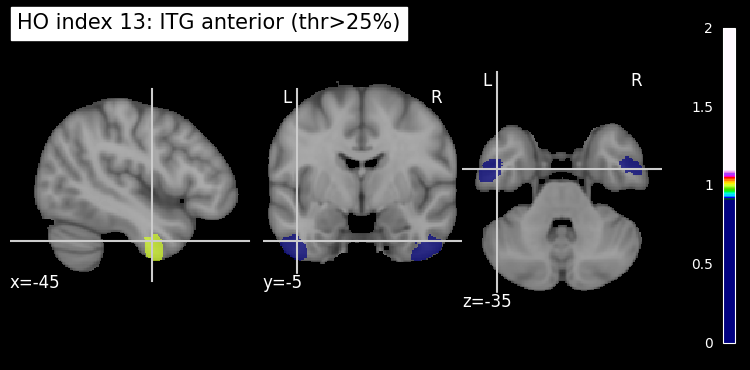

In [17]:
plotting.plot_roi(
    mask13, bg_img=bg_resamp,
    title=f"HO index 13: ITG anterior (thr>{thr}%)",
    display_mode="ortho", cut_coords=(-45, -5, -35),
)

plotting.show()

/scratch/midway3/katyzhang/conda/envs/nsd_fmri/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



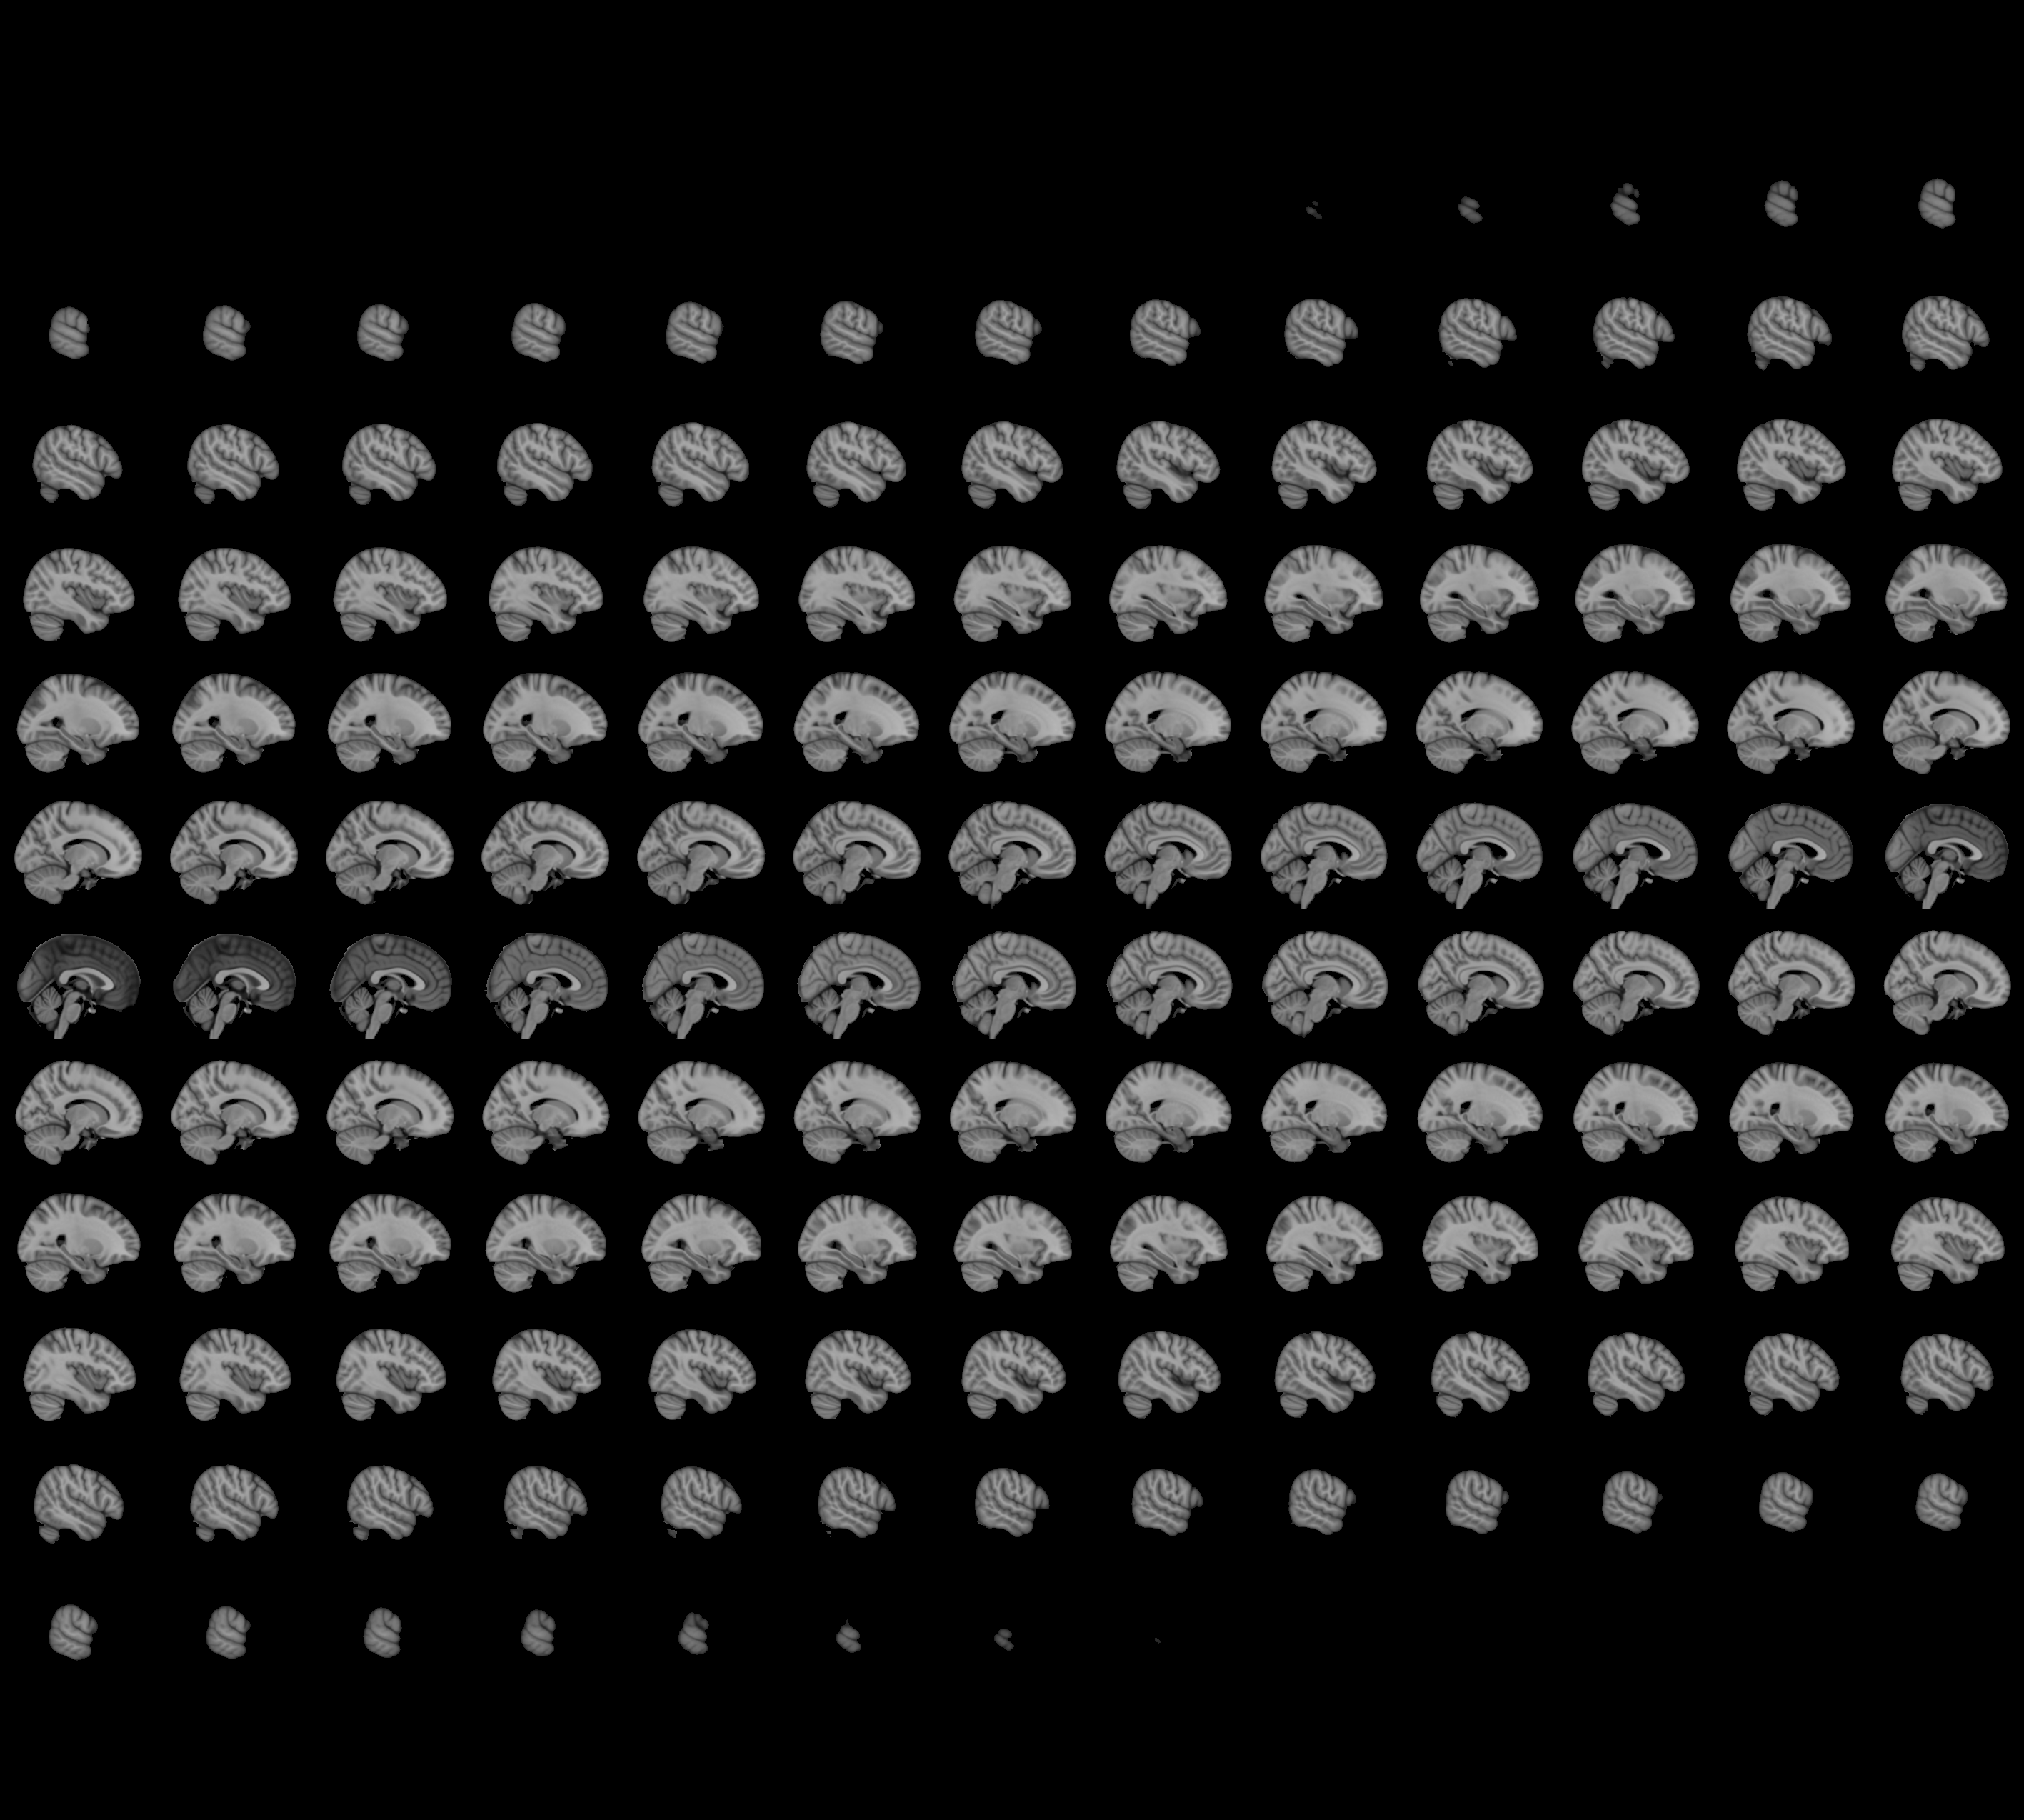
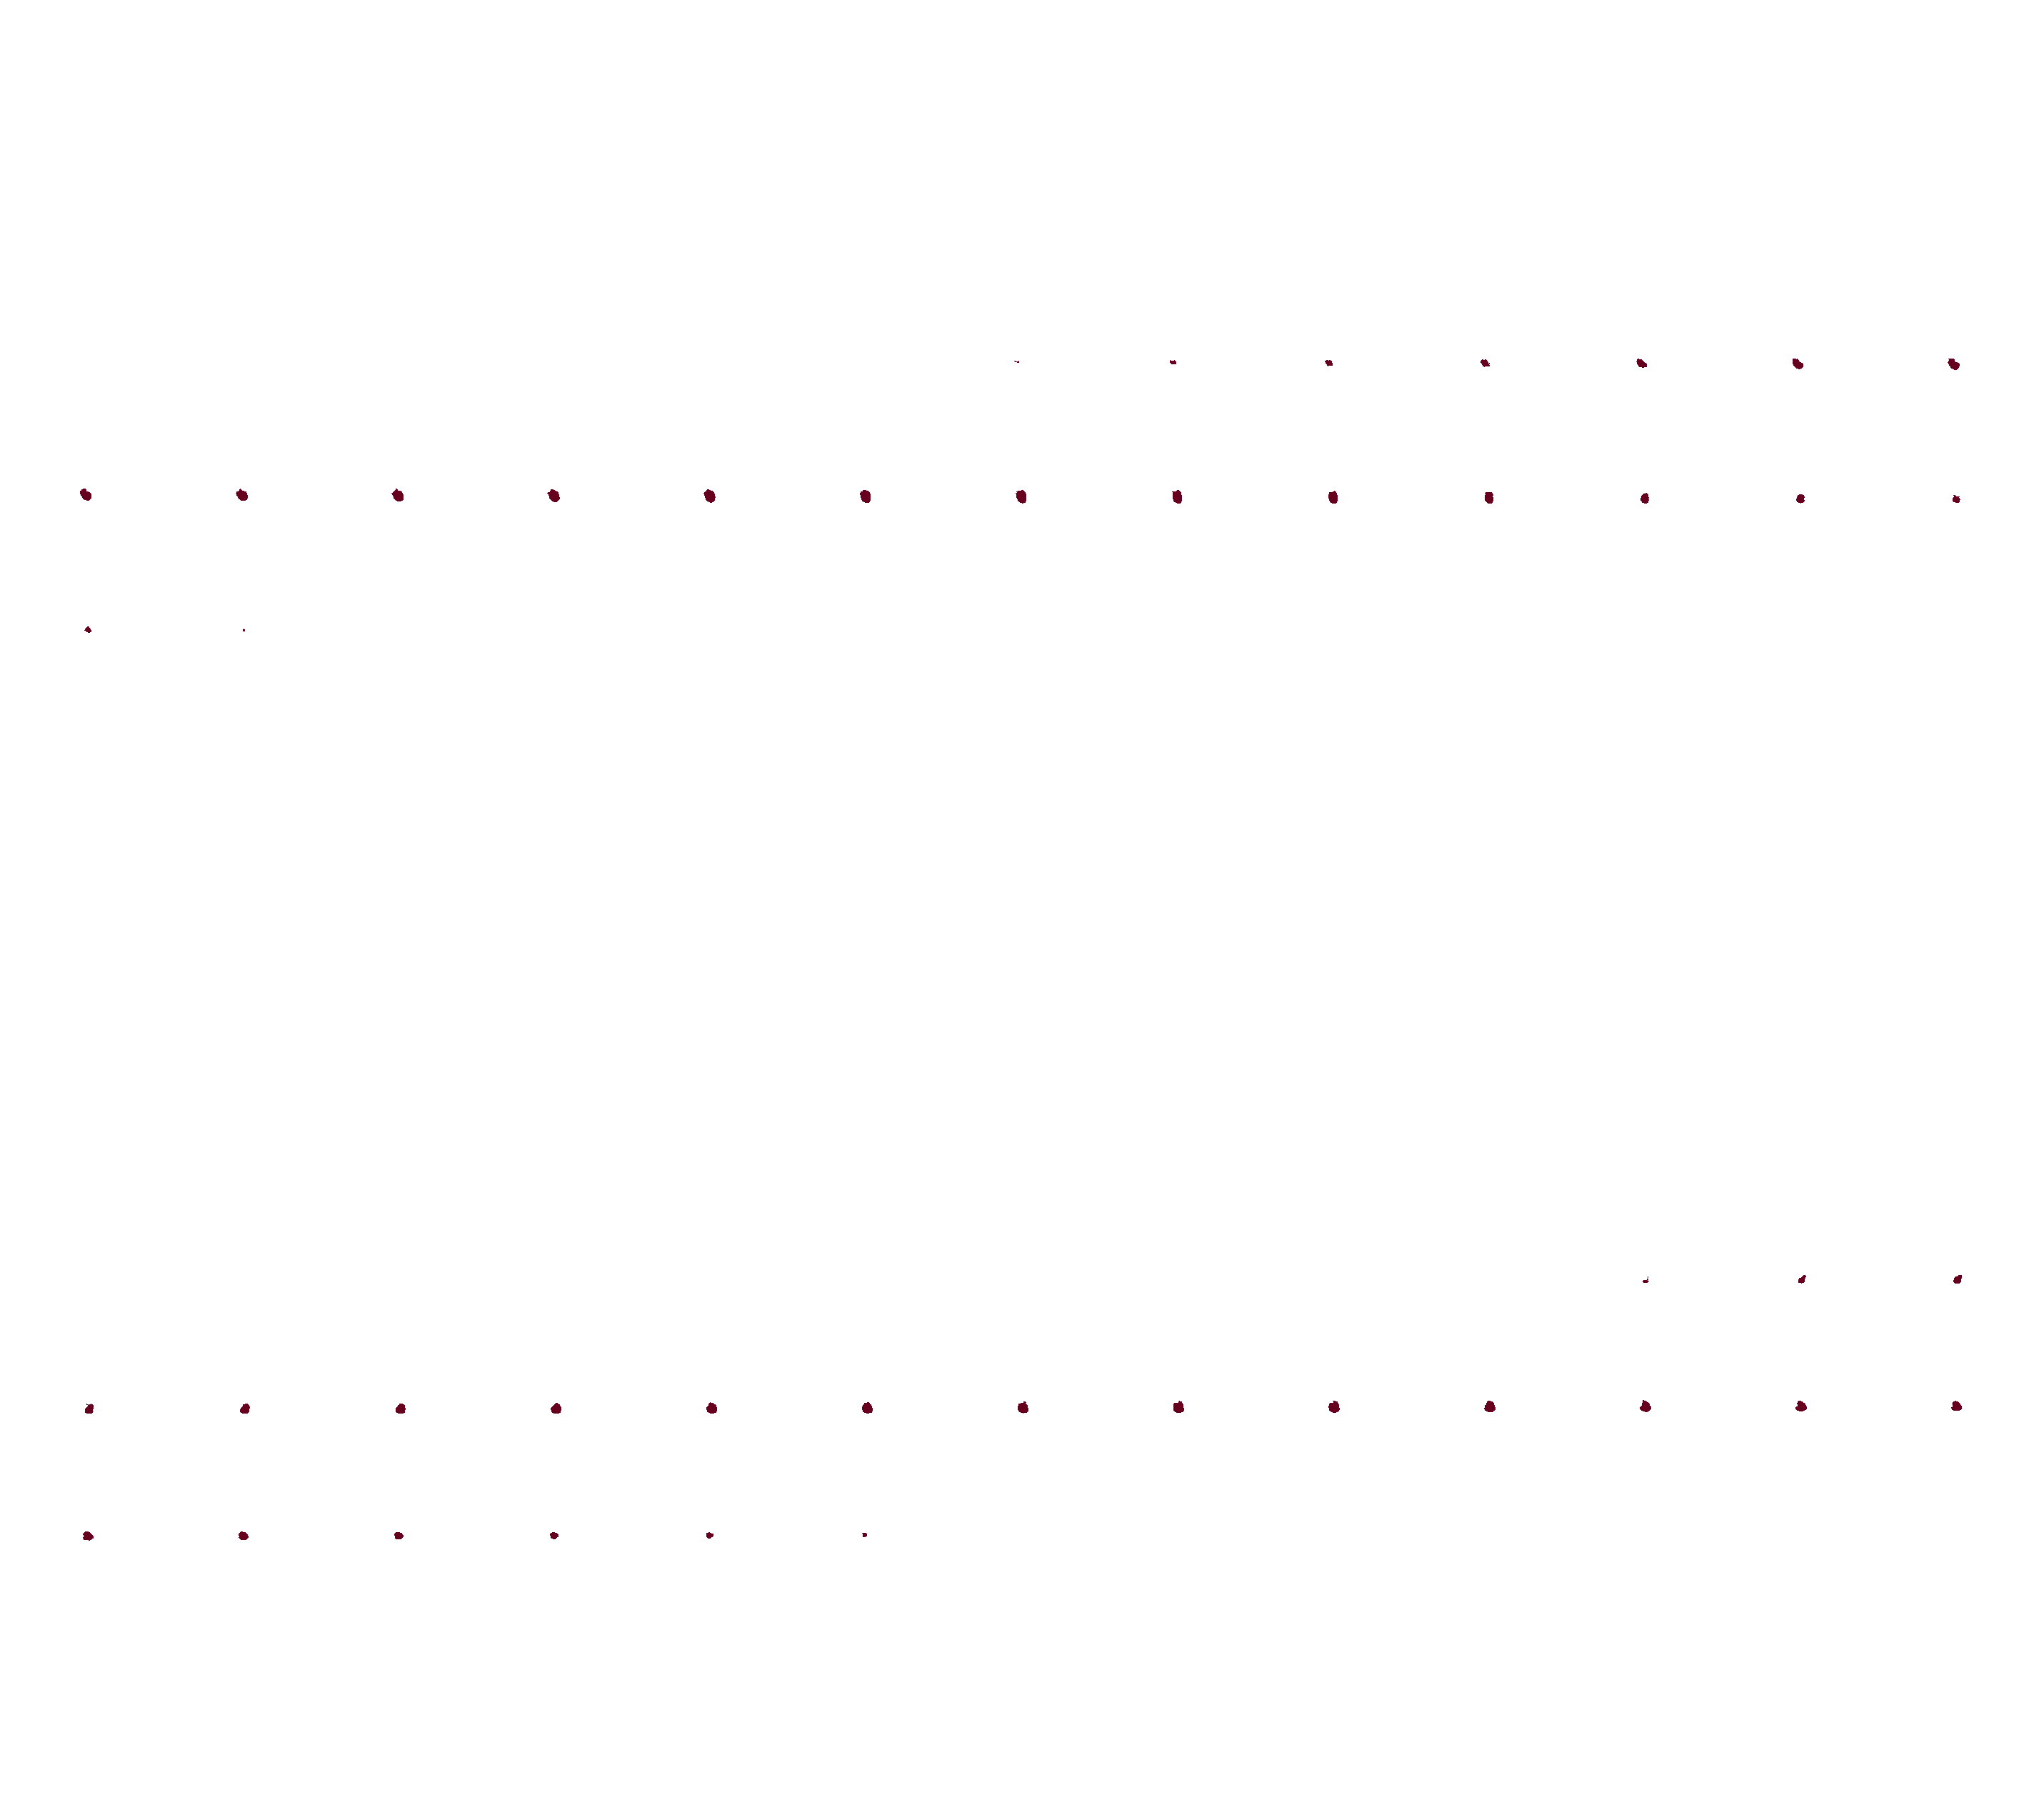

In [18]:
from nilearn import plotting
plotting.view_img(mask13, bg_img=bg_resamp)

## Data Preprocessing

#### (Error Removal) Check if there's any missing data

In [1]:
import os
import pandas as pd

ROOT_DIR = '/project/wilma/katyzhang/fMRI'
csv_path = os.path.join(ROOT_DIR, "preprocessing/ITG_H025_MNI/sub01/sub01_MNI_trials_13.csv")

df = pd.read_csv(csv_path)

In [30]:
import csv
import json
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path

ROOT = Path("/project/wilma/katyzhang/fMRI")
BETAS_DIR = ROOT / "nsddata/MNI/sub01_betas_fithrf"
TRIAL_TABLE = ROOT / "nsddata/design/sub01_trial_table.csv"

# --- add: path to memorability json ---
MEMO_JSON = ROOT / "preprocessing/memorability/memorability_sub01.json"

# Load trials
df_trials = (
    pd.read_csv(TRIAL_TABLE)
      .sort_values(["session", "trial_in_session"])
      .reset_index(drop=True)
)

# Load memorability map
with open(MEMO_JSON, "r") as f:
    memo_map = json.load(f)

# Normalize keys just in case (ensure 6-digit strings)
memo_map = {str(k).zfill(6): float(v) for k, v in memo_map.items()}

# create memorability by mapping nsd_image_index to memo_map
# memo_map keys are 6-digit strings like "042225"
# df["memorability"] = (
#     df["nsd_image_index"]
#       .astype(int) 
#       .astype(str)
#       .str.zfill(6)
#       .map(memo_map)                    # returns NaN if not found
# )

# check how many were missing
missing = df["memorability"].isna().sum()
print("Missing memorability:", missing)

Missing memorability: 0


In [2]:
import numpy as np
import pandas as pd

voxel_cols = [c for c in df.columns if c.startswith("index(13)_voxel")]

# memorability should be constant per image
df.groupby("nsd_image_index")["memorability"].nunique().value_counts()

df_img = (
    df.groupby("nsd_image_index", as_index=False)
      .agg({**{c: "mean" for c in voxel_cols}, "memorability": "mean"})
)

X = df_img[voxel_cols].to_numpy(dtype=np.float32)
y = df_img["memorability"].to_numpy(dtype=np.float32)

df_img.set_index("nsd_image_index")

,index(13)_voxel1,index(13)_voxel2,index(13)_voxel3,index(13)_voxel4,index(13)_voxel5,index(13)_voxel6,index(13)_voxel7,index(13)_voxel8,index(13)_voxel9,index(13)_voxel10,...,index(13)_voxel6130,index(13)_voxel6131,index(13)_voxel6132,index(13)_voxel6133,index(13)_voxel6134,index(13)_voxel6135,index(13)_voxel6136,index(13)_voxel6137,index(13)_voxel6138,memorability
nsd_image_index,,,,,,,,,,,,,,,,,,,,,
13,1346.666667,-125.000000,-484.000000,652.000000,621.666667,-623.333333,-497.666667,645.333333,840.666667,236.666667,...,2144.333333,717.333333,-525.333333,-1355.000000,-1647.666667,4139.000000,4147.000000,2946.666667,1003.666667,0.644387
27,-135.333333,110.666667,127.333333,375.666667,511.000000,-1525.333333,-1521.666667,-1089.333333,-657.666667,-303.000000,...,1267.000000,1905.000000,1492.333333,917.666667,961.333333,-744.000000,842.333333,799.000000,164.000000,0.851030
71,-653.333333,-283.000000,-962.666667,280.666667,635.000000,838.333333,834.333333,1092.000000,-6.333333,1321.666667,...,760.333333,2644.666667,3733.333333,3785.000000,2763.000000,209.666667,1205.333333,1778.000000,2616.000000,0.787993
85,-600.000000,374.333333,728.666667,272.000000,336.000000,188.666667,539.333333,4.000000,672.333333,168.666667,...,-1801.000000,-2397.333333,-1256.666667,56.666667,731.666667,1180.666667,-1511.000000,-2075.333333,-1132.000000,0.840908
88,1450.333333,430.666667,-680.666667,1046.333333,-137.000000,-623.333333,352.333333,1093.333333,728.000000,129.666667,...,1376.333333,3303.333333,3317.333333,2180.000000,1394.000000,257.000000,2150.000000,2585.666667,2067.666667,0.755239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72981,401.666667,773.000000,493.000000,962.000000,82.666667,-413.000000,-636.666667,2068.000000,206.333333,-1036.000000,...,3316.666667,3225.000000,2630.000000,1045.666667,-703.000000,2572.333333,2656.333333,2122.000000,1568.666667,0.713420
72983,-326.333333,-852.666667,-385.333333,20.666667,544.000000,-1236.000000,-537.333333,-519.000000,-1074.000000,554.333333,...,-1164.333333,-2430.333333,-2325.333333,-742.333333,345.666667,-311.666667,-246.333333,-636.333333,-940.333333,0.661695
72985,62.666667,-1341.666667,-737.333333,-797.333333,323.666667,-20.666667,677.333333,-1022.666667,-295.333333,-159.666667,...,2511.333333,3868.000000,4045.000000,3359.666667,2687.666667,-593.333333,-879.333333,-246.333333,914.333333,0.656946


In [ ]:
# csv_com_path = os.path.join(ROOT_DIR, "preprocessing/ITG_H025_MNI/sub01/sub01_MNI_images_13.csv")
# df_img.to_csv(csv_com_path, index="nsd_image_index")

#### (Outlier Detection) Using PCA, check wierd X
Catches weird images with unusually large overall beta patterns. And using PCA to reduce the dimension, becuase high-dimensional outliers are easier to see in a lower-dim subspace.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=50, random_state=0) # 50 dimensions
Z = pca.fit_transform(Xs)

# squared distance in PCA space
dist2 = np.sum((Z / (Z.std(axis=0) + 1e-8))**2, axis=1)

# robust cutoff using MAD
from scipy.stats import median_abs_deviation
mad = median_abs_deviation(dist2, scale="normal")
robust_z = (dist2 - np.median(dist2)) / (mad + 1e-8)

outlier_mask = robust_z > 3.5 # threshold
print("Outliers flagged:", outlier_mask.sum())

Outliers flagged: 158


In [8]:
# inspect the outlier cases
df_img["x_outlier"] = outlier_mask
df_img.loc[df_img["x_outlier"], ["nsd_image_index", "memorability"]].head()

,nsd_image_index,memorability
149,1249,0.715130
164,1361,0.645547
165,1362,0.698775
306,2548,0.593885
318,2672,0.758310


In [11]:
# drop them
# df_clean = df_img.loc[~df_img["x_outlier"]].reset_index(drop=True)
# X_clean = df_clean[voxel_cols].to_numpy(np.float32)
# y_clean = df_clean["memorability"].to_numpy(np.float32)
df_clean

,nsd_image_index,index(13)_voxel1,index(13)_voxel2,index(13)_voxel3,index(13)_voxel4,index(13)_voxel5,index(13)_voxel6,index(13)_voxel7,index(13)_voxel8,index(13)_voxel9,...,index(13)_voxel6131,index(13)_voxel6132,index(13)_voxel6133,index(13)_voxel6134,index(13)_voxel6135,index(13)_voxel6136,index(13)_voxel6137,index(13)_voxel6138,memorability,x_outlier
0,13,1346.666667,-125.000000,-484.000000,652.000000,621.666667,-623.333333,-497.666667,645.333333,840.666667,...,717.333333,-525.333333,-1355.000000,-1647.666667,4139.000000,4147.000000,2946.666667,1003.666667,0.644387,False
1,27,-135.333333,110.666667,127.333333,375.666667,511.000000,-1525.333333,-1521.666667,-1089.333333,-657.666667,...,1905.000000,1492.333333,917.666667,961.333333,-744.000000,842.333333,799.000000,164.000000,0.851030,False
2,71,-653.333333,-283.000000,-962.666667,280.666667,635.000000,838.333333,834.333333,1092.000000,-6.333333,...,2644.666667,3733.333333,3785.000000,2763.000000,209.666667,1205.333333,1778.000000,2616.000000,0.787993,False
3,85,-600.000000,374.333333,728.666667,272.000000,336.000000,188.666667,539.333333,4.000000,672.333333,...,-2397.333333,-1256.666667,56.666667,731.666667,1180.666667,-1511.000000,-2075.333333,-1132.000000,0.840908,False
4,88,1450.333333,430.666667,-680.666667,1046.333333,-137.000000,-623.333333,352.333333,1093.333333,728.000000,...,3303.333333,3317.333333,2180.000000,1394.000000,257.000000,2150.000000,2585.666667,2067.666667,0.755239,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9837,72981,401.666667,773.000000,493.000000,962.000000,82.666667,-413.000000,-636.666667,2068.000000,206.333333,...,3225.000000,2630.000000,1045.666667,-703.000000,2572.333333,2656.333333,2122.000000,1568.666667,0.713420,False
9838,72983,-326.333333,-852.666667,-385.333333,20.666667,544.000000,-1236.000000,-537.333333,-519.000000,-1074.000000,...,-2430.333333,-2325.333333,-742.333333,345.666667,-311.666667,-246.333333,-636.333333,-940.333333,0.661695,False
9839,72985,62.666667,-1341.666667,-737.333333,-797.333333,323.666667,-20.666667,677.333333,-1022.666667,-295.333333,...,3868.000000,4045.000000,3359.666667,2687.666667,-593.333333,-879.333333,-246.333333,914.333333,0.656946,False
9840,72992,671.333333,290.333333,330.666667,1054.333333,-305.000000,-231.666667,1055.666667,268.000000,587.000000,...,1252.333333,2061.666667,2159.666667,1795.000000,-930.333333,-303.000000,598.666667,1109.000000,0.670540,False


In [ ]:
# csv_clean_path = os.path.join(ROOT_DIR, "preprocessing/ITG_H025_MNI/sub01/sub01_MNI_images_clean_13.csv")
# df_clean.to_csv(csv_clean_path, index="nsd_image_index")

#### (Distribution Check)
After averaging voxel betas across repeats and removing outliers in X, the memorability (y) distribution remains very similar to the original. This indicates that the preprocessing primarily affected the feature space rather than selectively filtering particular y values. 

The target distribution shows a mild left tail (fewer low-memorability samples), so I will monitor errors across quantiles and consider reweighting to avoid underfitting the lower end.

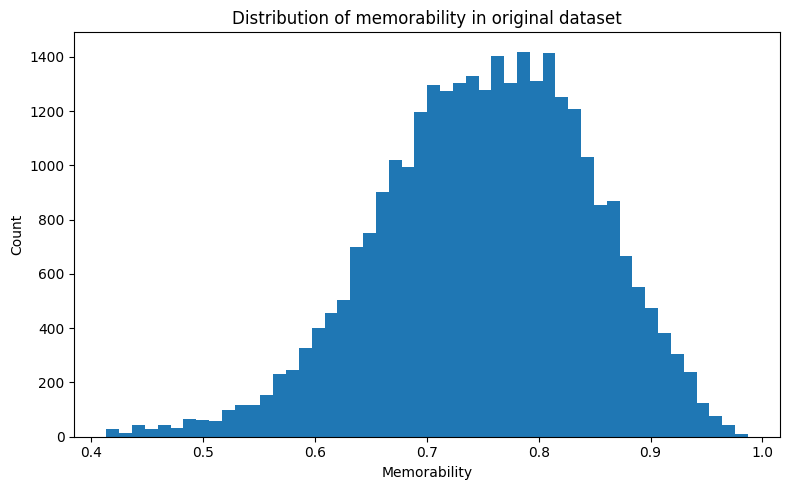

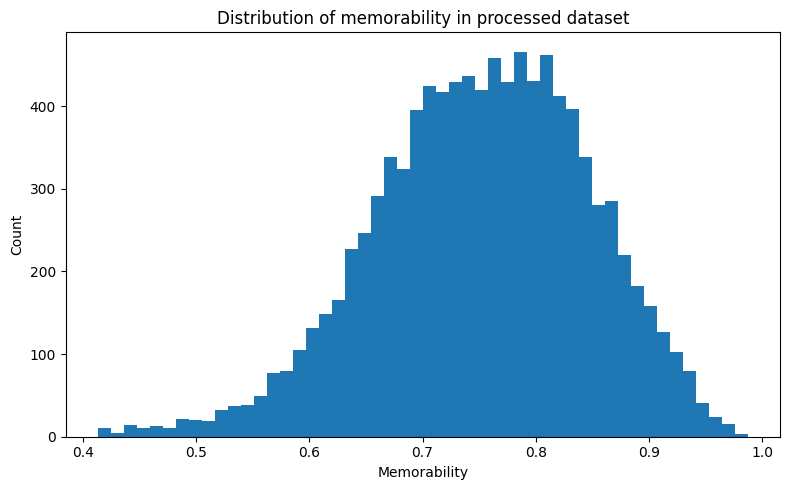

n (non-missing): 9842
min: 0.4134588837623596
max: 0.9870542883872986
mean: 0.752282574978744
median: 0.7572095990180969


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# For df
vals = (
    df["memorability"]
    .dropna()
    .astype(float)
    .to_numpy()
)

plt.figure(figsize=(8, 5))
plt.hist(vals, bins=50)
plt.xlabel("Memorability")
plt.ylabel("Count")
plt.title("Distribution of memorability in original dataset")
plt.tight_layout()
plt.show()

# For df_clean
vals = (
    df_clean["memorability"]
    .dropna()
    .astype(float)
    .to_numpy()
)

plt.figure(figsize=(8, 5))
plt.hist(vals, bins=50)
plt.xlabel("Memorability")
plt.ylabel("Count")
plt.title("Distribution of memorability in processed dataset")
plt.tight_layout()
plt.show()

# numeric summary
print("n (non-missing):", vals.size)
print("min:", float(vals.min()))
print("max:", float(vals.max()))
print("mean:", float(vals.mean()))
print("median:", float(np.median(vals)))

# Model Exploration

In [1]:
import os
import pandas as pd

ROOT_DIR = '/project/wilma/katyzhang/fMRI'
csv_clean_path = os.path.join(ROOT_DIR, "preprocessing/ITG_H025_MNI/sub01/sub01_MNI_images_clean_13.csv")

df_clean = pd.read_csv(csv_clean_path)
df_clean

,Unnamed: 0,nsd_image_index,index(13)_voxel1,index(13)_voxel2,index(13)_voxel3,index(13)_voxel4,index(13)_voxel5,index(13)_voxel6,index(13)_voxel7,index(13)_voxel8,...,index(13)_voxel6131,index(13)_voxel6132,index(13)_voxel6133,index(13)_voxel6134,index(13)_voxel6135,index(13)_voxel6136,index(13)_voxel6137,index(13)_voxel6138,memorability,x_outlier
0,0,13,1346.666667,-125.000000,-484.000000,652.000000,621.666667,-623.333333,-497.666667,645.333333,...,717.333333,-525.333333,-1355.000000,-1647.666667,4139.000000,4147.000000,2946.666667,1003.666667,0.644387,False
1,1,27,-135.333333,110.666667,127.333333,375.666667,511.000000,-1525.333333,-1521.666667,-1089.333333,...,1905.000000,1492.333333,917.666667,961.333333,-744.000000,842.333333,799.000000,164.000000,0.851030,False
2,2,71,-653.333333,-283.000000,-962.666667,280.666667,635.000000,838.333333,834.333333,1092.000000,...,2644.666667,3733.333333,3785.000000,2763.000000,209.666667,1205.333333,1778.000000,2616.000000,0.787993,False
3,3,85,-600.000000,374.333333,728.666667,272.000000,336.000000,188.666667,539.333333,4.000000,...,-2397.333333,-1256.666667,56.666667,731.666667,1180.666667,-1511.000000,-2075.333333,-1132.000000,0.840908,False
4,4,88,1450.333333,430.666667,-680.666667,1046.333333,-137.000000,-623.333333,352.333333,1093.333333,...,3303.333333,3317.333333,2180.000000,1394.000000,257.000000,2150.000000,2585.666667,2067.666667,0.755239,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9837,9837,72981,401.666667,773.000000,493.000000,962.000000,82.666667,-413.000000,-636.666667,2068.000000,...,3225.000000,2630.000000,1045.666667,-703.000000,2572.333333,2656.333333,2122.000000,1568.666667,0.713420,False
9838,9838,72983,-326.333333,-852.666667,-385.333333,20.666667,544.000000,-1236.000000,-537.333333,-519.000000,...,-2430.333333,-2325.333333,-742.333333,345.666667,-311.666667,-246.333333,-636.333333,-940.333333,0.661695,False
9839,9839,72985,62.666667,-1341.666667,-737.333333,-797.333333,323.666667,-20.666667,677.333333,-1022.666667,...,3868.000000,4045.000000,3359.666667,2687.666667,-593.333333,-879.333333,-246.333333,914.333333,0.656946,False
9840,9840,72992,671.333333,290.333333,330.666667,1054.333333,-305.000000,-231.666667,1055.666667,268.000000,...,1252.333333,2061.666667,2159.666667,1795.000000,-930.333333,-303.000000,598.666667,1109.000000,0.670540,False


In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Model Training

### (Train/Test Split)

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

TARGET_COL = "memorability"
ID_COL = "nsd_image_index"

# get data
voxel_cols = [c for c in df_clean.columns if "voxel" in c]  # robust fallback
assert TARGET_COL in df_clean.columns, "memorability column missing"
assert len(voxel_cols) > 0, "No voxel columns found. Adjust voxel_cols selection."

X = df_clean[voxel_cols].to_numpy(dtype=np.float32)
y = df_clean[TARGET_COL].to_numpy(dtype=np.float32)

print("X shape:", X.shape, "y shape:", y.shape)


X shape: (9842, 6138) y shape: (9842,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

### Model 1: Lasso Regression (feature selection)

In [5]:
# create pipeline
lasso_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("model", Lasso(max_iter=5000, random_state=42))
])

# hyperparameters
lasso_grid = {
    "model__alpha": np.logspace(-4, 0, 9),
}

# find the best hyperparameters
lasso_search = GridSearchCV(
    lasso_pipe,
    param_grid=lasso_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)
lasso_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,{'model__alpha': array([1.0000...00000000e+00])}
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [ ]:
# inspect Lasso selected features
best_lasso = lasso_search.best_estimator_
lasso_coefs = best_lasso.named_steps["model"].coef_
selected = np.where(np.abs(lasso_coefs) > 1e-10)[0] # where the coefs is not too little
print(f"\nLasso selected {len(selected)} / {X.shape[1]} features.")

# Map indices back to voxel column names (top 30 by abs weight)
top = np.argsort(np.abs(lasso_coefs))[::-1][:30]
top_features = [(voxel_cols[i], float(lasso_coefs[i])) for i in top if abs(lasso_coefs[i]) > 0]
print("\nTop Lasso features (voxel, coef):")
# Loop: for each top_feature
for feat, coef in top_features:
    print(feat, coef)


Lasso selected 35 / 6138 features.

Top Lasso features (voxel, coef):
index(13)_voxel3100 0.004261114168912172
index(13)_voxel3097 0.0028252757620066404
index(13)_voxel3148 0.0026797091122716665
index(13)_voxel5406 -0.002599073573946953
index(13)_voxel3101 0.0017765264492481947
index(13)_voxel4787 -0.0014876683708280325
index(13)_voxel4289 -0.0012477359268814325
index(13)_voxel3095 0.0012222351506352425
index(13)_voxel5345 -0.0011535336961969733
index(13)_voxel1607 -0.0009129788377322257
index(13)_voxel1377 -0.0008522614953108132
index(13)_voxel3149 0.0008241362520493567
index(13)_voxel5472 -0.0007965509430505335
index(13)_voxel3485 -0.000784777628723532
index(13)_voxel3079 0.0007657200912944973
index(13)_voxel3104 0.0007504326058551669
index(13)_voxel3493 0.0007450961275026202
index(13)_voxel3067 0.0004651619237847626
index(13)_voxel3500 -0.0004606081638485193
index(13)_voxel4874 -0.00042960900464095175
index(13)_voxel5064 -0.00033209938555955887
index(13)_voxel4273 -0.00031842620228

### Model 2: Gradient Boosting Regressor

In [ ]:
# create regressor
gbr = GradientBoostingRegressor(random_state=42)

# hyperparameters
gbr_grid = {
    "n_estimators": [100, 300, 600],
    "learning_rate": [0.05, 0.1, 0.2],
    # keep trees shallow to reduce overfitting
    "max_depth": [2, 3],
}

# find the best hyperparameters
gbr_search = GridSearchCV(
    gbr,
    param_grid=gbr_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)
# fit the model
gbr_search.fit(X_train, y_train)

### Model 3: Decision Tree Regressor (baseline)

In [ ]:
# building the DT
dt = DecisionTreeRegressor(random_state=42)

# hyperparameters
dt_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_leaf": [1, 5, 10, 25],
}

# find the best hyperparameters
dt_search = GridSearchCV(
    dt,
    param_grid=dt_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1
)
# fit the model
dt_search.fit(X_train, y_train)

### Model 4: Stacking Regressor (tree improvement)

In [ ]:
# first layer: DT + Lasso + KNN
stack_estimators = [
    ("dt", DecisionTreeRegressor(random_state=42, max_depth=dt_search.best_params_.get("max_depth", None),
                                 min_samples_leaf=dt_search.best_params_.get("min_samples_leaf", 1))),
    ("lasso", Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=lasso_search.best_params_["model__alpha"], max_iter=5000, random_state=42))
    ])),
    ("knn", Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=15))
    ])),
]

# final layer: GradientBoosting
final_est = GradientBoostingRegressor(
    random_state=42,
    n_estimators=gbr_search.best_params_.get("n_estimators", 300),
    learning_rate=gbr_search.best_params_.get("learning_rate", 0.1),
    max_depth=gbr_search.best_params_.get("max_depth", 3),
)

# stack together
stack = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=final_est,
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

# fit the model (not searching for the best output, which would be time-consuming)
stack.fit(X_train, y_train)

## Model Evaluation

### Based on metrics

In [ ]:
def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    # get predicted value for current model
    yhat_tr = model.predict(X_tr)
    yhat_te = model.predict(X_te)

    out = {
        "model": name,
        "train_R2": r2_score(y_tr, yhat_tr), # R2 for training data
        "test_R2": r2_score(y_te, yhat_te), # R2 for testing data
        "test_MAE": mean_absolute_error(y_te, yhat_te), # absolute error
        "test_MSE": mean_squared_error(y_te, yhat_te), # squared error
    }
    return out

# Get a list of results
results = []
results.append(eval_model("Lasso (best CV)", lasso_search.best_estimator_, X_train, y_train, X_test, y_test))
results.append(eval_model("GradBoost (best CV)", gbr_search.best_estimator_, X_train, y_train, X_test, y_test))
results.append(eval_model("DecisionTree (best CV)", dt_search.best_estimator_, X_train, y_train, X_test, y_test))
results.append(eval_model("Stacking (DT + others)", stack, X_train, y_train, X_test, y_test))

df_results = pd.DataFrame(results).sort_values("test_R2", ascending=False) # sort by test_R2
print(df_results)

print("\nBest hyperparameters:")
print("Lasso:", lasso_search.best_params_)
print("GradBoost:", gbr_search.best_params_)
print("DecisionTree:", dt_search.best_params_)

In [ ]:
# Visualization
plt.figure(figsize=(7,4))
plt.bar(df_results["model"], df_results["test_MAE"].iloc[0])
plt.xlabel("Model"); plt.ylabel("Test MAE"); plt.title("Test MAE by model")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.bar(df_results["model"], df_results["test_R2"])
plt.xlabel("Model"); plt.ylabel("Test R^2"); plt.title("Test R^2 by model")
plt.tight_layout(); plt.show()

### Stability Check

In [ ]:
import matplotlib.pyplot as plt

def voxel_count_curve(model, X_train, y_train, X_test, y_test, voxel_counts,
                      n_repeats=5, random_state=0):
    rng = np.random.default_rng(random_state)
    # If only using less X, would the model perform good as well?
    p = X_train.shape[1]
    means = []
    stds = []
    # Loop: for each voxel_amount
    for k in voxel_counts:
        r2s = []
        # Loop: for n times
        for _ in range(n_repeats):
            # randomly select k features from X as the input columns
            idx = rng.choice(p, size=k, replace=False)
            model.fit(X_train[:, idx], y_train) # fit the model
            yhat = model.predict(X_test[:, idx])
            r2s.append(r2_score(y_test, yhat)) # calculate the r2
        means.append(np.mean(r2s))
        stds.append(np.std(r2s))
    return np.array(means), np.array(stds)

# Using the best model
stab_model = gbr_search.best_estimator_

voxel_counts = [50, 100, 250, 500, 1000, 2000, 4000, X.shape[1]]
means, stds = voxel_count_curve(stab_model, X_train, y_train, X_test, y_test, voxel_counts, n_repeats=5)

plt.figure(figsize=(7, 5))
plt.errorbar(voxel_counts, means, yerr=stds, fmt='o-')
plt.xscale("log")
plt.xlabel("Number of voxels (log scale)")
plt.ylabel("Test R^2 (mean ± sd)")
plt.title("Voxel-count stability curve")
plt.tight_layout()
plt.show()

## Result analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

In [ ]:
# Grab the fitted/best models
models = {
    "Lasso": lasso_search.best_estimator_,
    "DecisionTree": dt_search.best_estimator_,
    "GradBoost": gbr_search.best_estimator_,
    "Stacking": stack,
}

### Visualize the decision tree
Limit depth for readability

In [ ]:
from sklearn.tree import plot_tree

# get the best decision tree
best_dt = dt_search.best_estimator_
plt.figure(figsize=(18, 6))
plot_tree(best_dt, max_depth=3, feature_names=voxel_cols, filled=False)
plt.title("DecisionTreeRegressor (top 3 levels shown)")
plt.tight_layout()
plt.show()

### Lasso top-n coefficients

In [ ]:
# get the best lasso model
best_lasso = lasso_search.best_estimator_
coefs = best_lasso.named_steps["model"].coef_

# calculate the abs_order
abs_order = np.argsort(np.abs(coefs))[::-1]
top_n = 20
top_idx = [i for i in abs_order[:top_n] if np.abs(coefs[i]) > 0]

# top->down based on abs_coef
lasso_top = pd.DataFrame({
    "feature": [voxel_cols[i] for i in top_idx],
    "coef": [coefs[i] for i in top_idx],
    "abs_coef": [abs(coefs[i]) for i in top_idx],
}).sort_values("abs_coef", ascending=False)

print(f"\n=== Lasso Top-{top_n} Coefficients (non-zero) ===")
print(lasso_top[["feature", "coef"]].head(top_n))

plt.figure(figsize=(8, 6))
plt.barh(lasso_top["feature"].iloc[::-1], lasso_top["coef"].iloc[::-1])
plt.xlabel("Coefficient")
plt.title(f"Lasso top coefficients (n={min(top_n, len(lasso_top))})")
plt.tight_layout()
plt.show()

### Error analysis
To identify failure cases and compare across models

In [ ]:
def error_table(model, model_name, Xtest, ytest, df_meta, top_k=20):
    # get prediction of the model
    yhat = model.predict(Xtest)
    resid = yhat - ytest
    out = df_meta.copy()
    out[f"pred_{model_name}"] = yhat
    out[f"abs_err_{model_name}"] = np.abs(resid)
    out[f"err_{model_name}"] = resid
    return out.sort_values(f"abs_err_{model_name}", ascending=False).head(top_k)

# metadata to show alongside errors
meta = pd.concat([X_test, y_test], ignore_index=True)

worst_lasso = error_table(best_lasso, "Lasso", X_test, y_test, meta, top_k=15)
worst_dt    = error_table(best_dt, "DT", X_test, y_test, meta, top_k=15)
worst_gb    = error_table(gbr_search.best_estimator_, "GB", X_test, y_test, meta, top_k=15)
worst_stack = error_table(stack, "Stack", X_test, y_test, meta, top_k=15)

print("\n=== Worst Lasso errors ===")
print(worst_lasso)

print("\n=== Worst DecisionTree errors ===")
print(worst_dt)

print("\n=== Worst GradBoost errors ===")
print(worst_gb)

print("\n=== Worst Stacking errors ===")
print(worst_stack)

### Compare residual distributions across models

In [ ]:
plt.figure(figsize=(7,5))
# Loop: for each model
for name, m in models.items():
    resid = m.predict(X_test) - y_test # get residual value
    plt.hist(resid, bins=40, alpha=0.5, label=name)
plt.xlabel("Residual (pred - true)")
plt.ylabel("Count")
plt.title("Residual distributions (test set)")
plt.legend()
plt.tight_layout()
plt.show()

### Quantile-based error check
Do errors concentrate in the tail?

In [ ]:
def quantile_error_breakdown(model, Xtest, ytest, n_bins=5):
    # get prediction
    yhat = model.predict(Xtest)
    abs_err = np.abs(yhat - ytest) # absolute errors
    # group y into n_bins
    bins = pd.qcut(ytest, q=n_bins, duplicates="drop")
    return pd.DataFrame({"y_true": ytest, "abs_err": abs_err, "bin": bins}).groupby("bin")["abs_err"].agg(["count","mean","std"])

print("\n=== Quantile MAE breakdown ===")
for name, m in models.items():
    print(f"\n{name}")
    print(quantile_error_breakdown(m, X_test, y_test, n_bins=5))